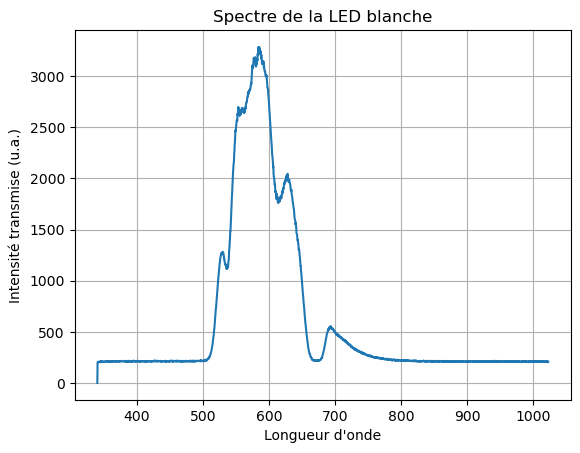

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger le fichier
# sep='\s+' : sépare par espaces ou tabulations
# decimal=',' : indique que les nombres utilisent la virgule comme séparateur décimal
# comment='>' : ignore les lignes qui commencent par '>' (comme >>>>>End)
df = pd.read_csv("data/CORDEES8_HUILE.txt", 
                 sep='\s+', 
                 header=None, 
                 decimal=',', 
                 comment='>')

# Plot
plt.figure(2)
plt.plot(df[0], df[1], linestyle='-')
plt.xlabel("Longueur d'onde")
plt.ylabel("Intensité transmise (u.a.)")
plt.title("Spectre de la LED blanche")
plt.grid(True)
plt.show()

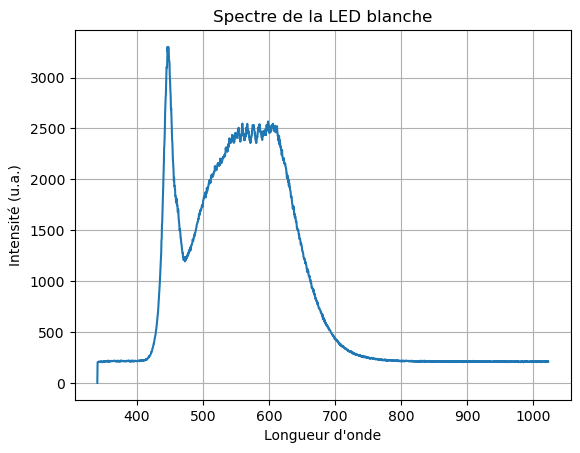

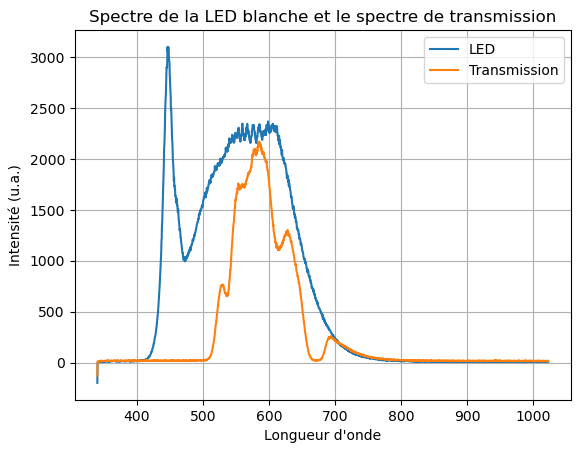

In [7]:
# Charger le fichier
# sep='\s+' : sépare par espaces ou tabulations
# decimal=',' : indique que les nombres utilisent la virgule comme séparateur décimal
# comment='>' : ignore les lignes qui commencent par '>' (comme >>>>>End)
df_led = pd.read_csv("data/CORDEES.txt", 
                 sep='\s+', 
                 header=None, 
                 decimal=',', 
                 comment='>')

# Plot
plt.figure(2)
plt.plot(df_led[0], df_led[1], linestyle='-')
plt.xlabel("Longueur d'onde")
plt.ylabel("Intensité (u.a.)")
plt.title("Spectre de la LED blanche")
plt.grid(True)
plt.show()

plt.figure(3)
plt.plot(df_led[0], df_led[1]-200,  linestyle='-', label="LED")
plt.plot(df[0], 0.7*df[1]-130,  linestyle='-', label="Transmission")
plt.xlabel("Longueur d'onde")
plt.ylabel("Intensité (u.a.)")
plt.title("Spectre de la LED blanche et le spectre de transmission")
plt.grid(True)
plt.legend()
plt.show()

Le u.a. signifie unité arbitraire car la valeur ne représente pas une grandeur physique mais simplement un niveau d'intensité. <br>
Maintenant, nous allons essayer d'obtenir le spectre d'absorbance à partir de ces deux spectres. En effet, seul le spectre de transmittance ne permet pas de quantifier l'absorption car il faut connaître la distribution spectrale de la source illuminant l'huile d'olive. Pour cela, nous allons nous servir de la formule suivante : $$ A = \log_{10}\bigg (\frac{I_T(\lambda)}{I_0(\lambda)}\bigg) $$
où $I_T(\lambda)$ est l'intensité transmise et $I_0(\lambda)$ est l'intensité de la LED. L'indice 10 désigne la base du logarithme. Si $A=0$, cela siginifie que la transmission est totale et si $A=2$ la transmission est nulle.


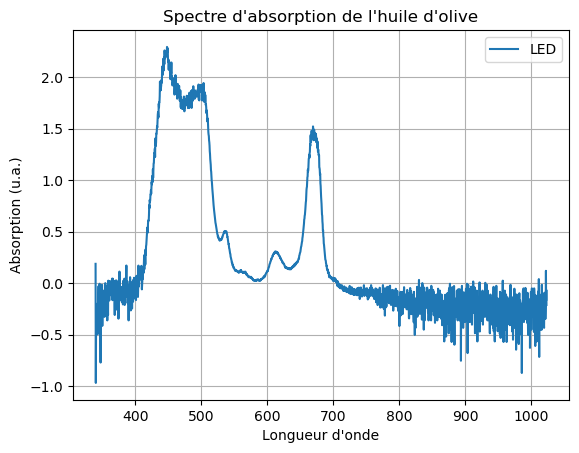

In [16]:
plt.figure(4)
plt.plot(df_led[0], -np.log10((0.7*df[1]-130)/(df_led[1]-200)),  linestyle='-', label="LED")
plt.xlabel("Longueur d'onde")
plt.ylabel("Absorption (u.a.)")
plt.title("Spectre d'absorption de l'huile d'olive")
plt.grid(True)
plt.legend()
plt.show()

Sur ce spectre, nous voyons deux contributions principales. Une dans le bleu (450 nm) et une autre dans le rouge (670 nm). Si vous vous souvenez, nous avions remarqué que la lumière bleue ne traversait pas l'huile d'olive (voir les <a href="#images_huile_bleu" >images</a> en dessous). Et bien nous en avons l'explication, l'absorption du bleu est très forte. Puisque l'absorption est linéaire en fonction de la longueur de la cuve (notre verre), plus le verre est grand, moins la lumière en sortie est intense. La loi reliant l'absorption à la longueur du verre est : $$ A=\varepsilon C L$$ où $\epsilon$ est le coefficient d'extinction molaire et $C$ la concentration. <br>
Toutes ces infos ne sont pas forcément nécessaire pour le poster où la présentation, mais ce sont de bonnes choses à savoir pour vous et pour répondre aux questions.

In [12]:
# Source - https://stackoverflow.com/a/38546126
# Posted by Salvador Dali
# Retrieved 2026-03-15, License - CC BY-SA 3.0

#Afficher une image depuis une cellule code

from IPython.display import HTML, display

display(HTML("<table><tr><td><img id=\"images_huile_bleu\" src='images/huile_bleu_side.png'></td><td><img src='images/huile_bleu_top.png'></td></tr></table>"))



,


En revanche, nous observons que le vert (532 nm pour le laser) est très peu aborbé. C'est ce qui explique que le faisceau lumineux du laser vert soit transmis. Mais il y a quand même un phénomène d'absorption car nous avons observé de la fluorescence rouge. <br>
affichage image depuis cellule md <img src="images/Pink_Panther.png">